In [318]:
include("../src/GeoUtils.jl");
import .GeoUtils as GU

using CSV
using GMT
using DataFrames
using H3.API
using LibGEOS

In [181]:
FocalMecDataGMT

3699×12 Matrix{Float64}:
 24.85  34.74  41.0  -0.17   0.32  -0.15   2.72  -0.41  -0.15  23.0  0.0  0.0
 19.67  40.96  10.0  -0.21   0.23  -0.02   0.8   -0.53   2.11  23.0  0.0  0.0
 19.67  40.82  10.0   0.05   0.0   -0.05   0.62  -0.16   1.31  23.0  0.0  0.0
 35.92  36.24  10.0  -3.19  -1.86   5.05   3.57  -1.53   1.5   23.0  0.0  0.0
 35.58  40.73  10.0   0.69  -5.97   5.28   0.11  -4.72  -4.45  23.0  0.0  0.0
 34.19  27.53  10.0  -4.1    8.68  -4.58   3.42  -2.91  -2.49  22.0  0.0  0.0
 26.15  34.19  20.0   3.06  -2.57  -0.5    0.61   0.07   0.73  23.0  0.0  0.0
 14.63  41.4   10.0  -6.35   4.99   1.36  -3.75   3.31  -1.39  22.0  0.0  0.0
  8.29  33.96  10.0   3.59  -3.29  -0.3   -0.11  -0.01  -1.55  23.0  0.0  0.0
 23.75  39.34  10.0  -0.28   2.73  -2.46  -0.24   1.74   0.09  23.0  0.0  0.0
  ⋮                                 ⋮                                ⋮    
 32.49  34.9    9.0   0.93  -0.86  -0.07   1.54  -0.89   0.2   24.0  0.0  0.0
 28.15  39.24  12.0  -0.9    1.01  -0.11  

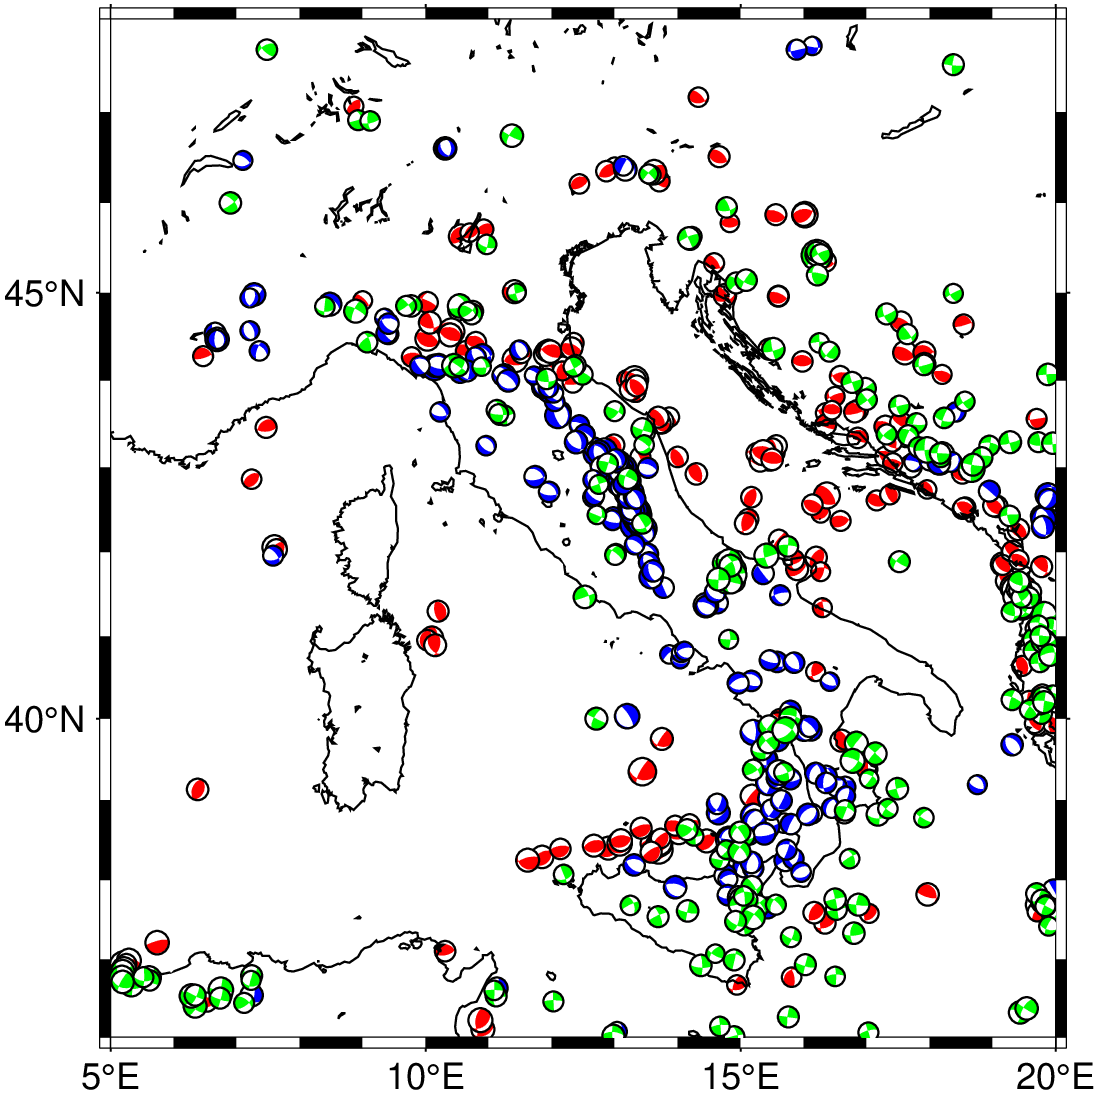

In [2]:
focal_mechanisms_path = "/Users/riccardo/Library/CloudStorage/GoogleDrive-riki.nucci3@gmail.com/Shared drives/BlockModels/CMED/Seismicity/FocalMechanisms/EuroMedCMT/28_Mar_2026/EuroMedCentrMomTensors-1774709126718_definitive.GMTpsmeca"
FocalMecData = CSV.read(focal_mechanisms_path,DataFrame,header=true,delim=",",ignorerepeated=true);
FocalMecDataGMT=Matrix(FocalMecData[:,[2,1,3,4,5,6,7,8,9,10,11,12]]);
cT, cS, cN =GU.LabelFocalMechanisms(FocalMecDataGMT[:,4],FocalMecDataGMT[:,5],FocalMecDataGMT[:,6],
				FocalMecDataGMT[:,7],FocalMecDataGMT[:,8],FocalMecDataGMT[:,9]);

FocalMecDataGMTThrust=FocalMecDataGMT[cT,:]
FocalMecDataGMTStrikeSlip=FocalMecDataGMT[cS,:]
FocalMecDataGMTNormal=FocalMecDataGMT[cN,:]

GMT.meca(FocalMecDataGMTThrust, Sd="0.2c",G="red",offset="",region=[5,20,36,48],J="M8c")
coast!()
GMT.meca!(FocalMecDataGMTNormal, Sd="0.2c",G="blue",offset="")
GMT.meca!(FocalMecDataGMTStrikeSlip, Sd="0.2c",G="green",offset="",show=true)

In [6]:
fthrust,fstrikeslip,fnormal =GU.FocalMechanismsType(FocalMecDataGMT[:,4],FocalMecDataGMT[:,5],FocalMecDataGMT[:,6],
				FocalMecDataGMT[:,7],FocalMecDataGMT[:,8],FocalMecDataGMT[:,9]);

x=sqrt.(fthrust)
y=sqrt.(fstrikeslip)
z=sqrt.(fnormal)

cond=((x.^2+y.^2+z.^2) .<= 1.01) .& ((x.^2+y.^2+z.^2) .>= 0.99)
print(sum(cond)==length(cond))

true

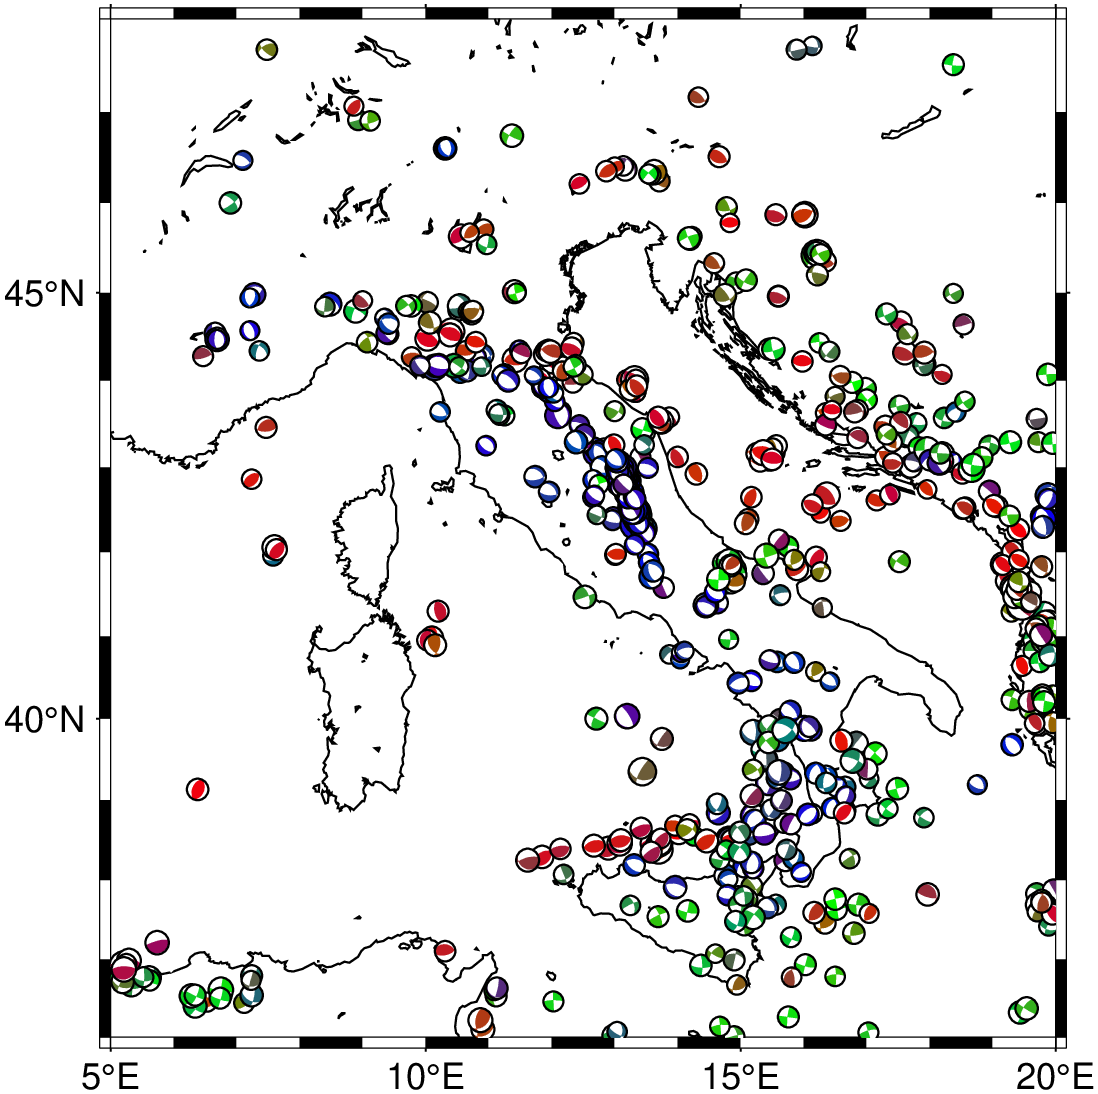

In [7]:
rgbcolors, _, _, _=GU.map_ternary_color_octant(x,y,z,[1,0,0],[0,1,0],[0,0,1])
hex_colors=GU.rgb_to_hex(rgbcolors)

GMT.basemap(region=[5,20,36,48],J="M8c")
coast!()
for i in eachindex(hex_colors)
    GMT.meca!(reshape(FocalMecDataGMT[i,:], 1, :), Sd="0.2c",G=hex_colors[i],offset="")
end
GMT.plot!([NaN],[NaN],show=true)

### Ternary Legend

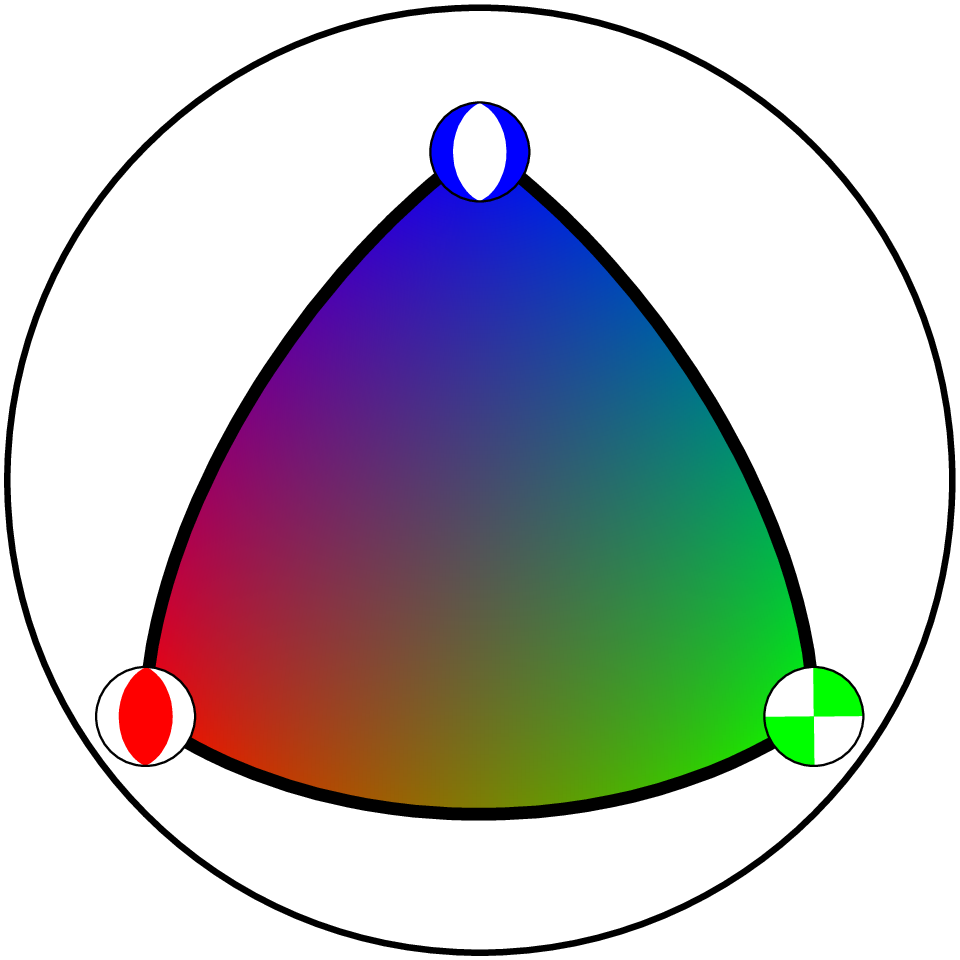

In [ ]:
lon = 0:0.5:90
lat = 0:0.5:90
A=fill("", length(lon), length(lat))
for i in eachindex(lon)
    for j in eachindex(lat)
        color,_,_,_=GU.map_ternary_color_octant(lon[i],lat[j],[1,0,0],[0,1,0],[0,0,1])
        hex_color=GU.rgb_to_hex(color)
        A[i,j]=hex_color[1]
    end
end




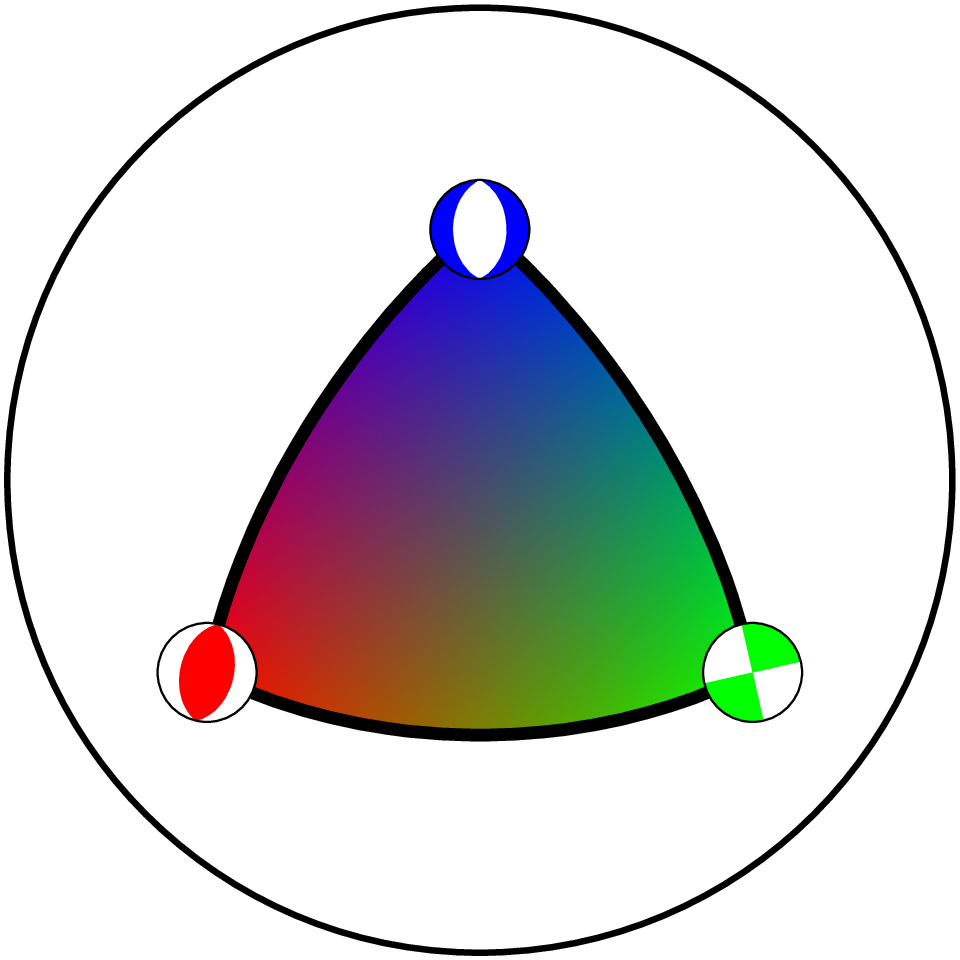

In [ ]:
GMT.basemap(J = "A45/45/8c",frame="g0a0",region=[0,90,0,90])
for i in eachindex(lon)
    for j in eachindex(lat)
        GMT.scatter!(x=lon[i],y=lat[j],fill=A[i,j], S="s2p")
    end
end
plot!([0,90,90,0],[0,0,90,0],pen="3p,black")
meca!([90 0 10  0 90 0 7 0 0],Sa="0.6c",fill="green")
meca!([45 89 10  0 45 -90 7 0 0],Sa="0.6c",fill="blue")
meca!([0 0 10  0 45 90 7 0 0],Sa="0.6c",fill="red") #!!! meca is not well oriented with G projection
GMT.plot!([NaN],[NaN],show=true)

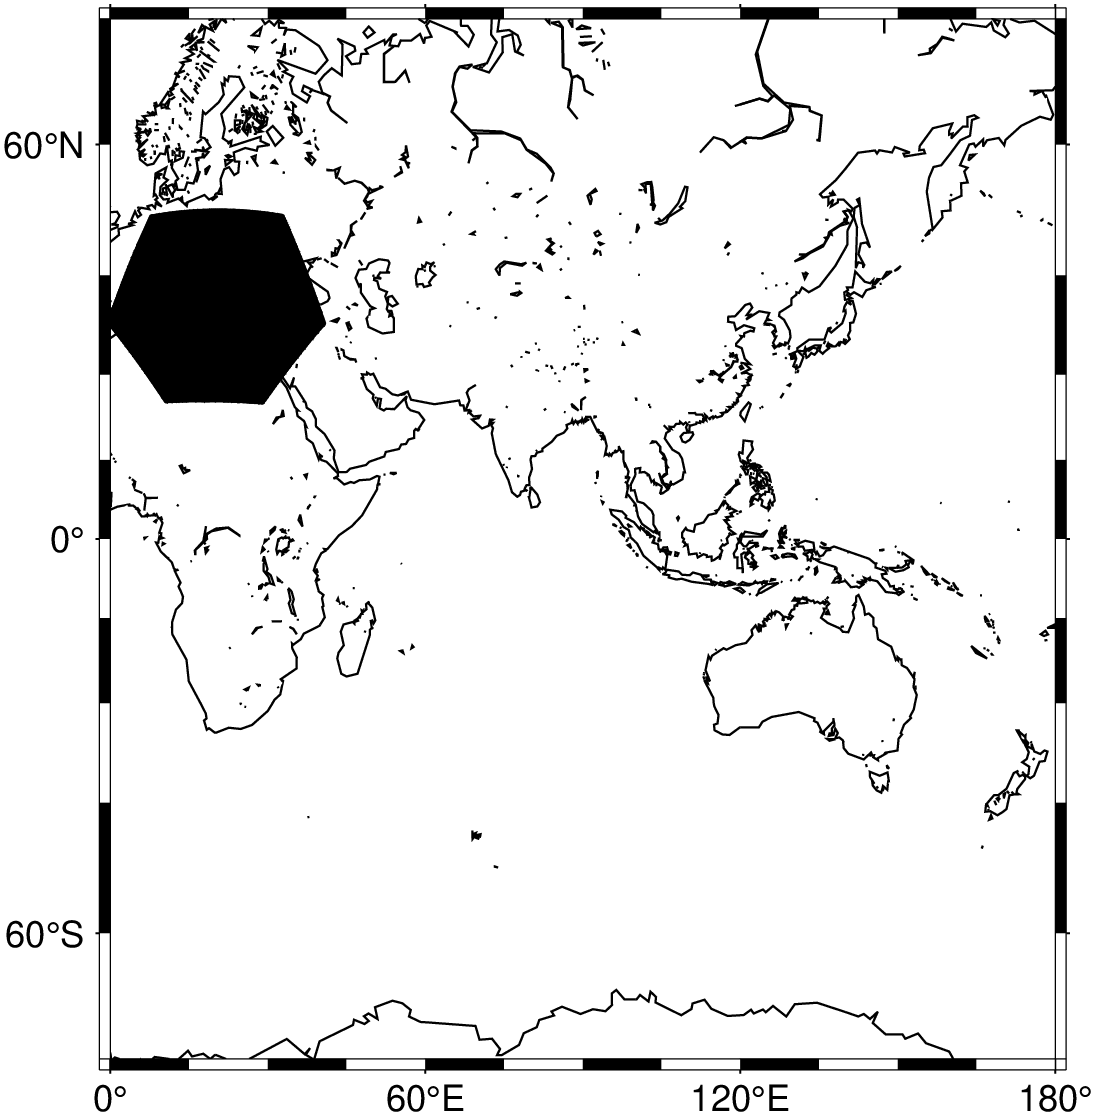

In [ ]:
cells=GU.makeH3grid(5,20,40,100) #order,lon,lat,nrings
GMT.basemap(region=[0,180,-70,70],J="M8c")
GMT.coast!()
for i in 1:size(cells,1)
    GMT.plot!(cells[i][:,1],cells[i][:,2])
end
GMT.plot!([NaN],[NaN],show=true)

In [353]:
region=[5,30,20,50]

my_count=0
SumFM = Matrix{Float64}(undef, 0, size(FocalMecDataGMT,2))  # matrice vuota con 3 colonne
hex_color_cells=[]

for i in 1:size(cells,1)
    my_cell=cells[i]

    test_lon=my_cell[1,1]
    test_lat=my_cell[1,2]

    if((test_lon >= region[1]) & (test_lon<=region[2]) & (test_lat >= region[3]) & (test_lat <= region[4]))
    
        polycontour=[my_cell[k,:] for k in 1:size(my_cell,1)];
        SwathPolygon=LibGEOS.Polygon([polycontour]);
        withinPoly=Bool[]
        for j=1:length(FocalMecDataGMT[:,1])
            onePoint=LibGEOS.Point(FocalMecDataGMT[j,1],FocalMecDataGMT[j,2]);
            push!(withinPoly,LibGEOS.intersects(onePoint,SwathPolygon));
        end

        myFM=FocalMecDataGMT[withinPoly,:]
        if(!isempty(myFM))
            my_count=my_count+1
            Mrr,Mtt,Mff,Mrt,Mrf,Mtf,exp=GU.MomentTensorsSum(myFM[:,4],myFM[:,5],myFM[:,6],myFM[:,7],myFM[:,8],myFM[:,9],myFM[:,10])
            SumFM=vcat(SumFM,[mean(my_cell[:,1]) mean(my_cell[:,2]) mean(myFM[:,3]) Mrr Mtt Mff Mrt Mrf Mtf exp 0 0])

            fthrust,fstrikeslip,fnormal =GU.FocalMechanismsType(Mrr,Mtt,Mff,Mrt,Mrf,Mtf);

            x=sqrt.(fthrust)
            y=sqrt.(fstrikeslip)
            z=sqrt.(fnormal)
            rgbcolor, _, _, _=GU.map_ternary_color_octant(x,y,z,[1,0,0],[0,1,0],[0,0,1])
            hex_color=GU.rgb_to_hex(rgbcolor)
            push!(hex_color_cells,hex_color[1])
        else

            push!(hex_color_cells,"")

        end
    else
            push!(hex_color_cells,"")
    end
end

In [358]:
GMT.basemap(region=[5,30,30,50],J="M8c")
GMT.coast!()
for i in 1:size(cells,1)
    if(hex_color_cells[i]!="")
        GMT.plot!(cells[i][:,1],cells[i][:,2],G=hex_color_cells[i])
    end
end
velo!([SumFM[:,1] SumFM[:,2] P_E_nor P_N_nor], pen="0.1p,black", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+gblack")
velo!([SumFM[:,1] SumFM[:,2] -P_E_nor -P_N_nor], pen="0.1p,black", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+gblack")
velo!([SumFM[:,1] SumFM[:,2] T_E_nor T_N_nor], pen="0.1p,gray", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+ggray")
velo!([SumFM[:,1] SumFM[:,2] -T_E_nor -T_N_nor], pen="0.1p,gray", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+ggray")

GMT.plot!([NaN],[NaN],name="FM.pdf")

In [256]:
cT_sum, cS_sum, cN_sum =GU.LabelFocalMechanisms(SumFM[:,4],SumFM[:,5],SumFM[:,6],
SumFM[:,7],SumFM[:,8],SumFM[:,9]);

SumFMThrust=SumFM[cT_sum,:]
SumFMStrikeSlip=SumFM[cS_sum,:]
SumFMNormal=SumFM[cN_sum,:]

477×12 Matrix{Float64}:
 19.2747   39.7695  10.0      -8.7    …   0.5    -4.8    22.0  0.0  0.0
 20.6733   39.9072  35.6667   -0.65      -5.09   -0.06   22.0  0.0  0.0
 20.5752   40.3275  15.0      -1.62      -0.33    0.28   24.0  0.0  0.0
 20.3648   40.6077  68.0      -2.2       -1.39   -1.46   23.0  0.0  0.0
 20.5564   39.4871   3.0      -0.916      0.919   0.463  23.0  0.0  0.0
 20.6867   40.4663  10.0     -10.573  …  -4.167   8.597  23.0  0.0  0.0
 21.1117   40.183   10.0      -1.61      -1.52   -0.32   22.0  0.0  0.0
 20.9032   40.4645  10.6667   -6.29      -1.93    2.75   23.0  0.0  0.0
 20.7984   40.6049  10.0      -3.845     -1.162   1.573  23.0  0.0  0.0
 20.2273   39.0669  51.0      -2.96      -0.59   -1.11   22.0  0.0  0.0
  ⋮                                   ⋱                        ⋮    
  7.16335  44.6395  10.0      -1.11      -0.39   -0.47   22.0  0.0  0.0
  7.21705  45.042   25.1     -10.7       -7.5     4.1    22.0  0.0  0.0
  7.12742  44.8997  11.0      -1.23   …   0

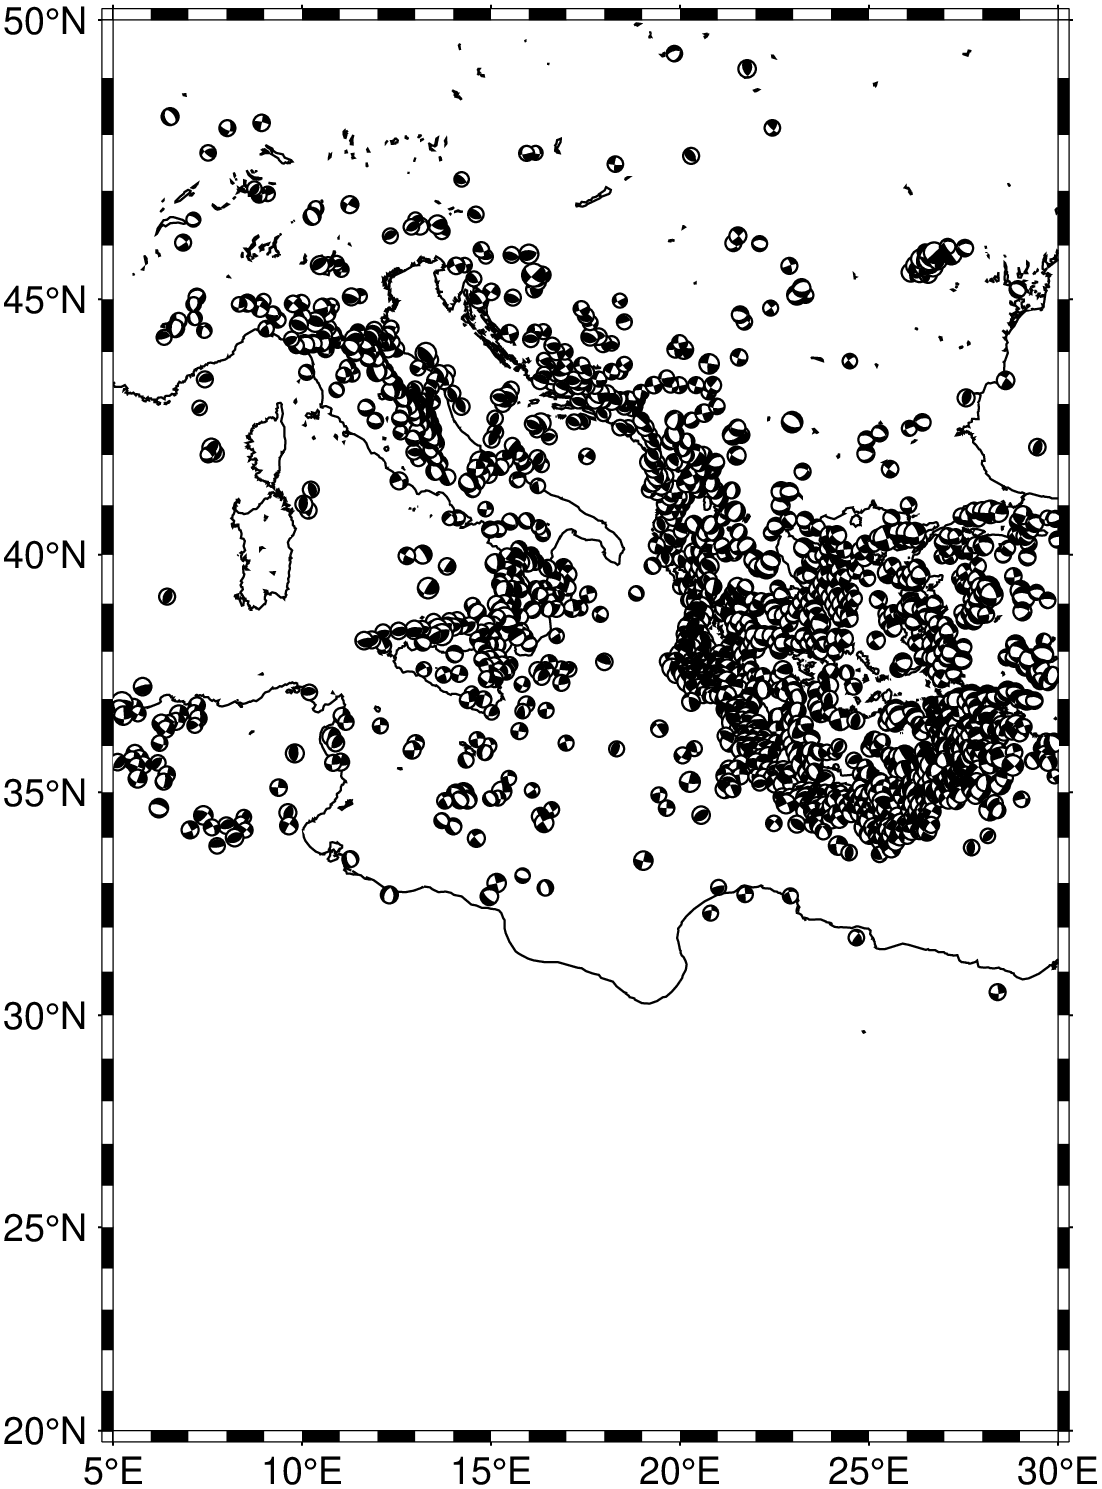

In [257]:
GMT.basemap(region=region,J="M8c")
coast!()
GMT.meca!(SumFM, Sd="0.15c",G="black",offset="")
GMT.plot!([NaN],[NaN],show=true)

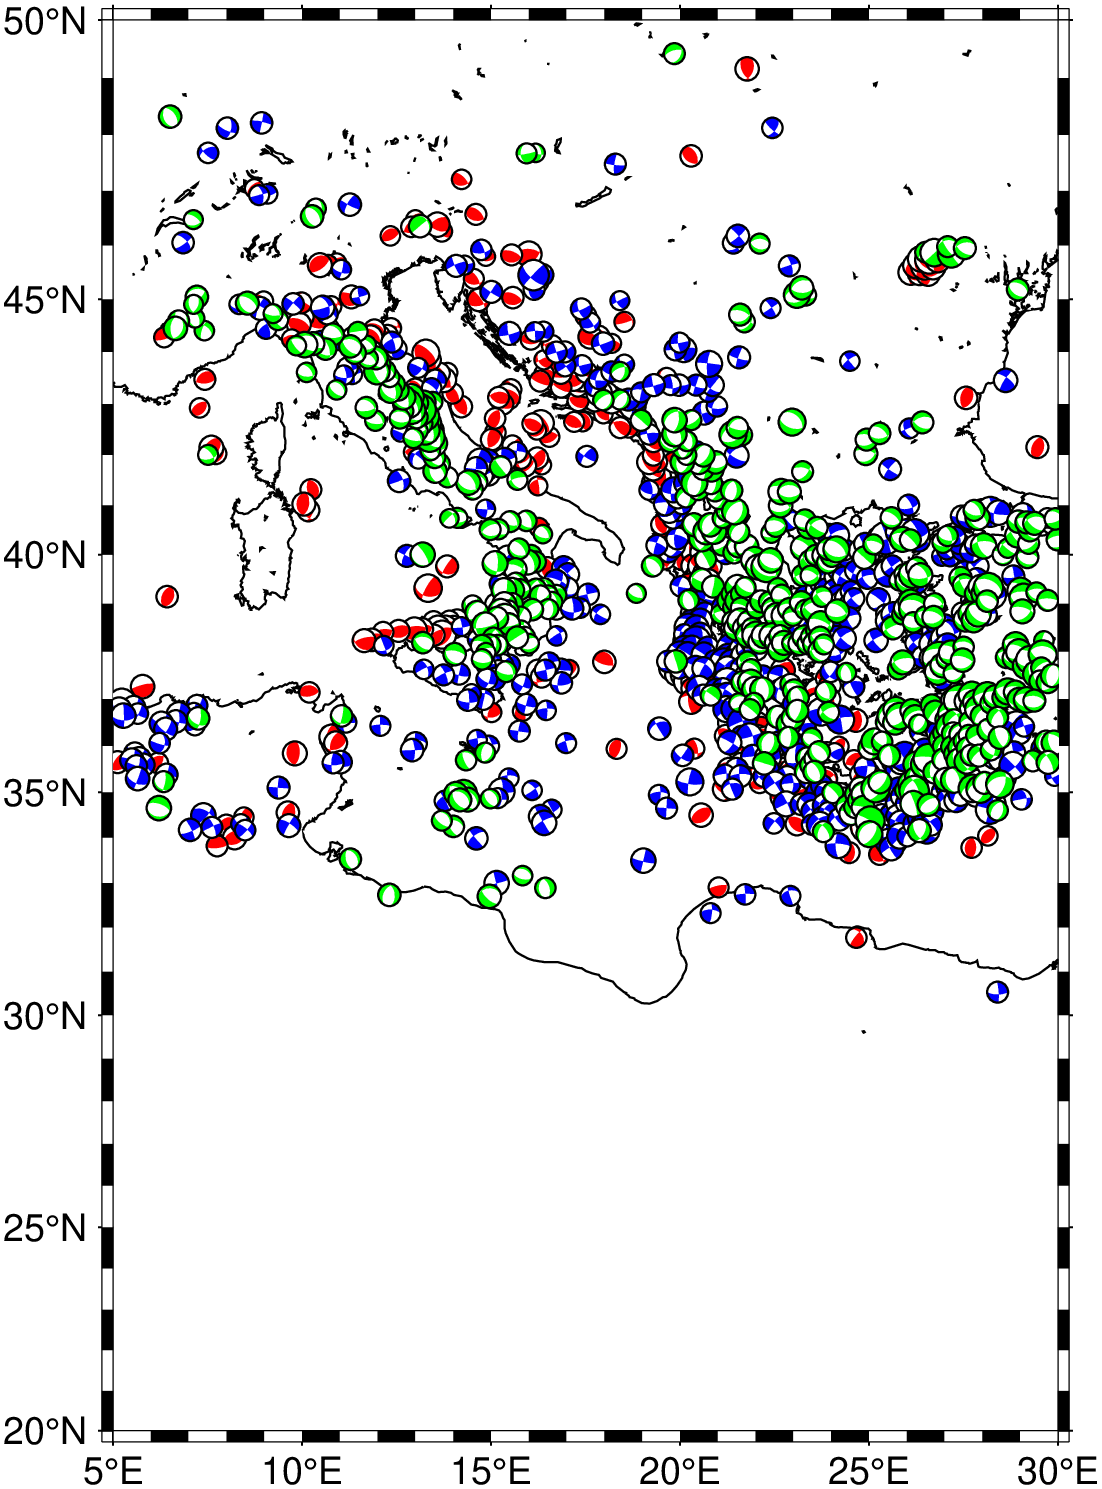

In [258]:
GMT.basemap(region=region,J="M8c")
GMT.coast!()
GMT.meca!(SumFMThrust, Sd="0.2c",G="red",offset="")
GMT.meca!(SumFMStrikeSlip, Sd="0.2c",G="blue",offset="")
GMT.meca!(SumFMNormal, Sd="0.2c",G="green",offset="")
GMT.plot!([NaN],[NaN],show=true)

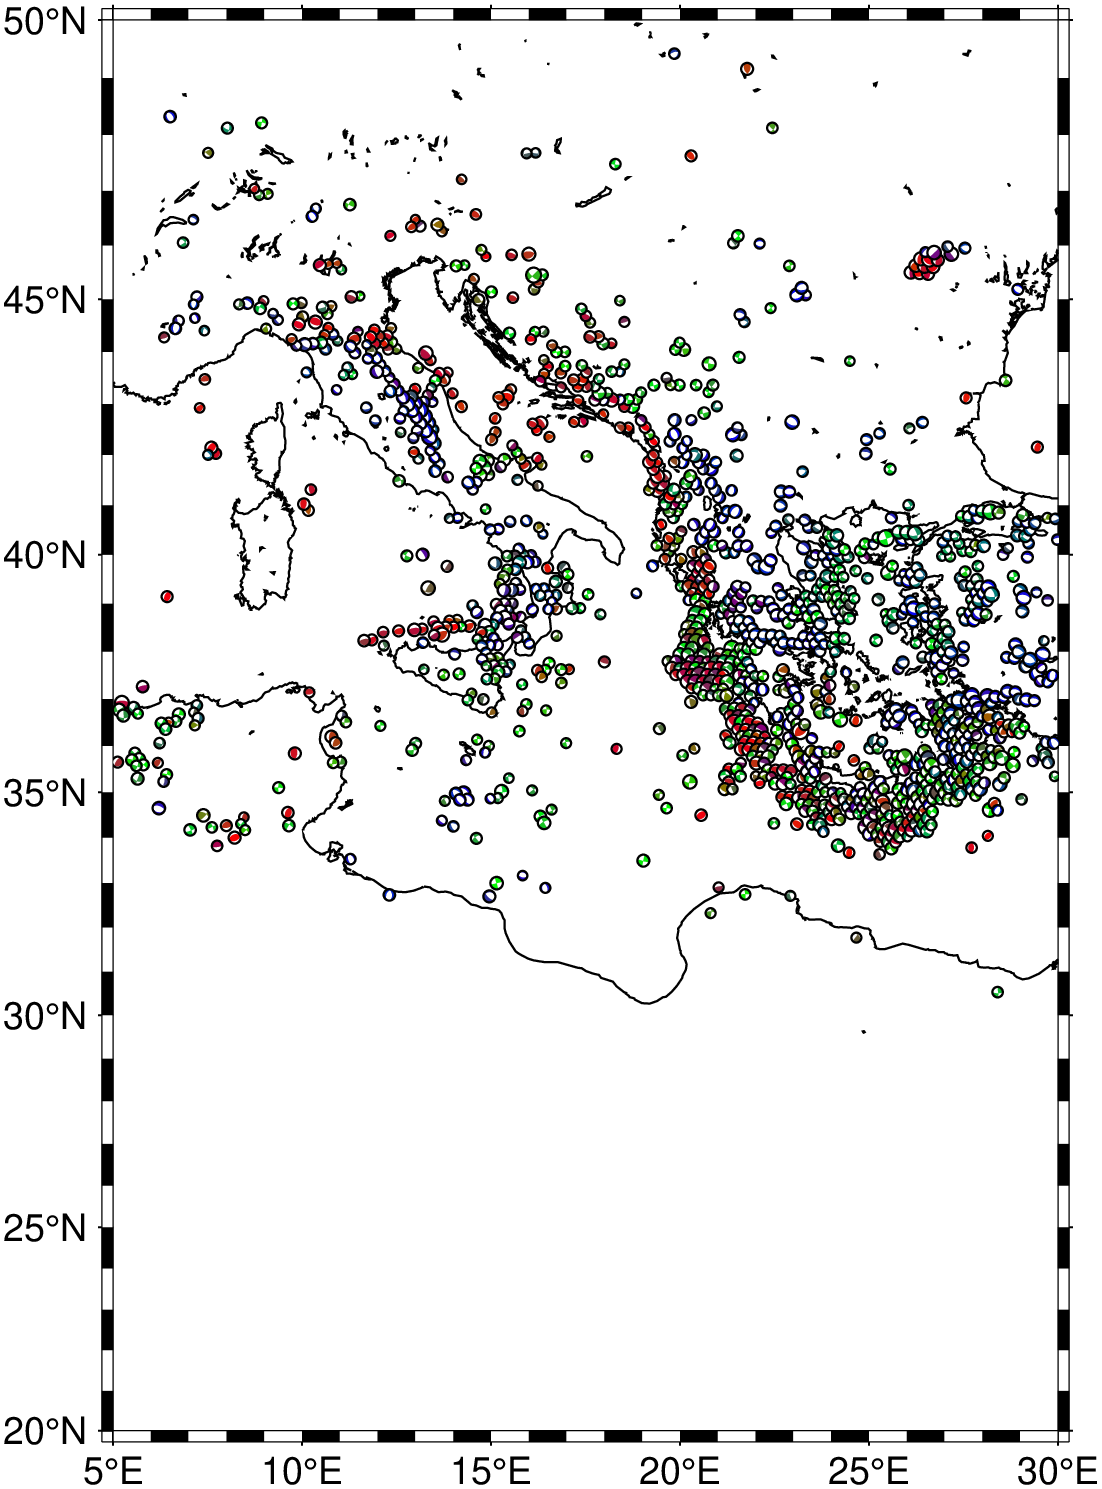

In [260]:
fthrust,fstrikeslip,fnormal =GU.FocalMechanismsType(SumFM[:,4],SumFM[:,5],SumFM[:,6],
SumFM[:,7],SumFM[:,8],SumFM[:,9]);

x=sqrt.(fthrust)
y=sqrt.(fstrikeslip)
z=sqrt.(fnormal)

cond=((x.^2+y.^2+z.^2) .<= 1.01) .& ((x.^2+y.^2+z.^2) .>= 0.99)
print(sum(cond)==length(cond))

rgbcolors, _, _, _=GU.map_ternary_color_octant(x,y,z,[1,0,0],[0,1,0],[0,0,1])
hex_colors=GU.rgb_to_hex(rgbcolors)

GMT.basemap(region=region,J="M8c")
coast!()
for i in eachindex(hex_colors)
    GMT.meca!(reshape(SumFM[i,:], 1, :), Sd="0.1c",G=hex_colors[i],offset="")
end
GMT.plot!([NaN],[NaN],show=true)

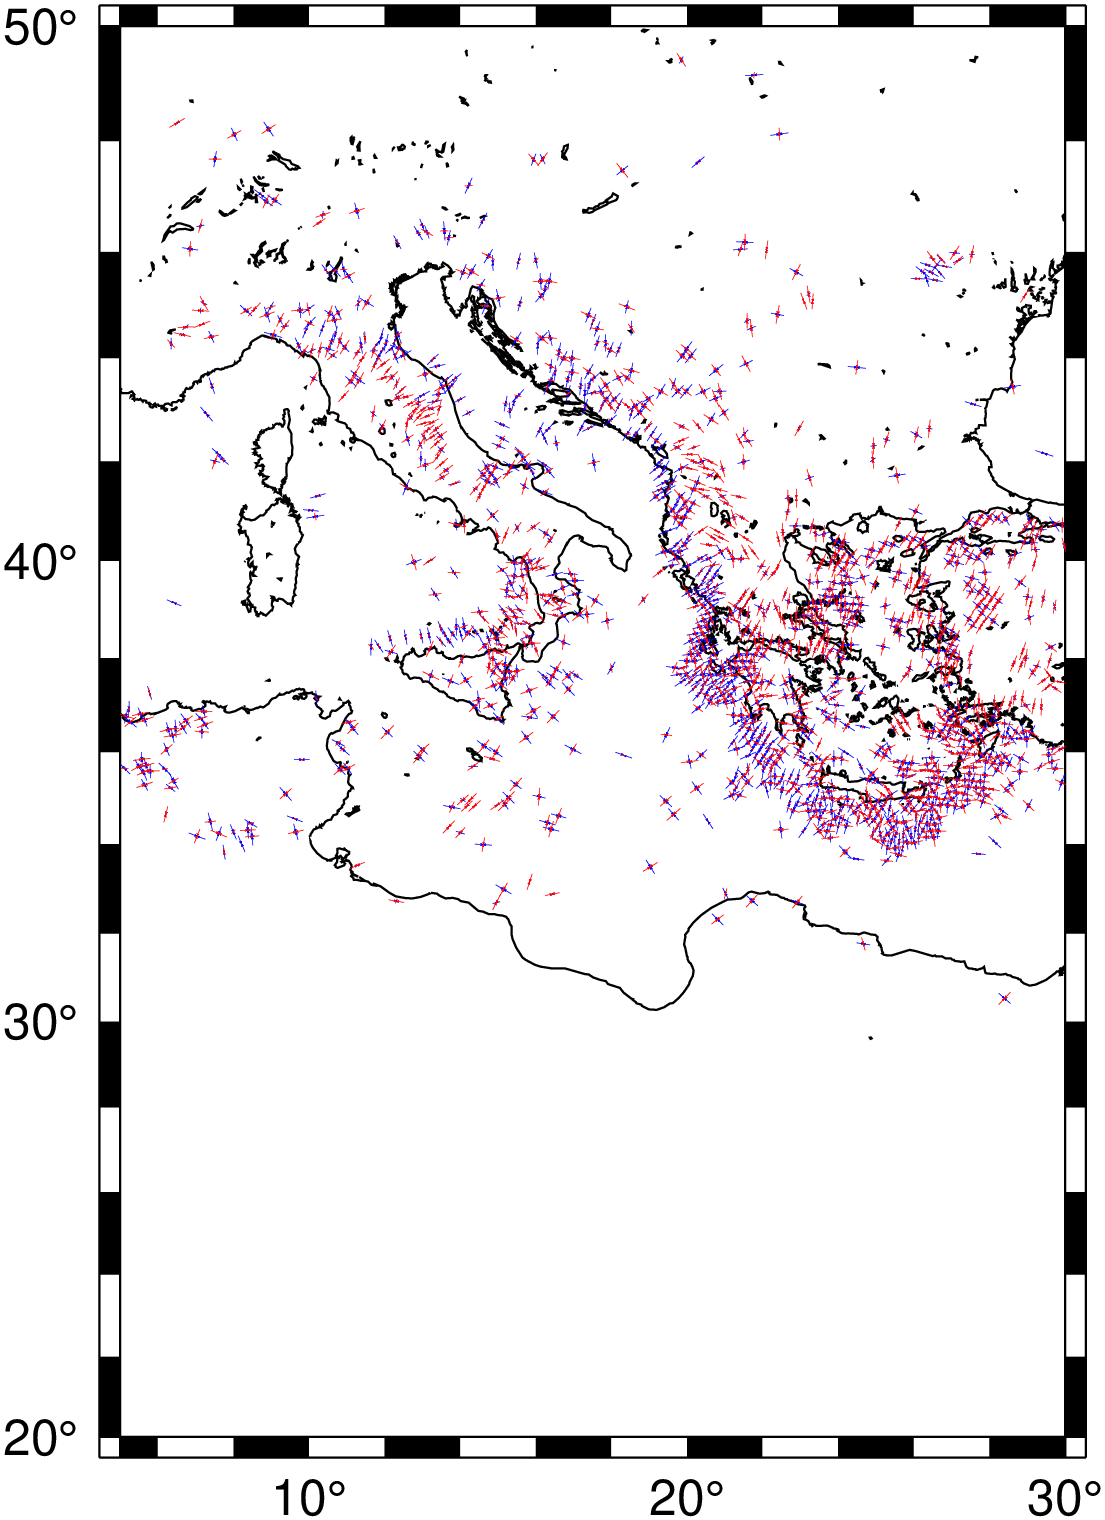

In [339]:
MinEigenValues,InterEigenValues,MaxEigenValues,IsoPart,Pvectors,Nvectors,Tvectors=GU.PrincipalAxesFM(SumFM[:,4],SumFM[:,5],SumFM[:,6],SumFM[:,7],SumFM[:,8],SumFM[:,9],exp=SumFM[:,10])
P_E=Pvectors[:,1] .* MinEigenValues
P_N=Pvectors[:,2] .* MinEigenValues
T_E=Tvectors[:,1] .* MaxEigenValues
T_N=Tvectors[:,2] .* MaxEigenValues

azimuths=[]
for i in 1:length(P_E)

    azimuth=atan(P_E[i],P_N[i]);
    if(azimuth<0)
        azimuth=azimuth+2*pi
    end
    azimuthDeg=azimuth*180/pi
    push!(azimuths,azimuthDeg)
end

matrix_hor=[SumFM[:,1] SumFM[:,2] MaxEigenValues MinEigenValues azimuths]
matrix_hor=Matrix{Float64}(matrix_hor)

P_E_nor=P_E ./ sqrt.(MinEigenValues.^2 + InterEigenValues.^2 .+ MaxEigenValues.^2)
P_N_nor=P_N ./ sqrt.(MinEigenValues.^2 + InterEigenValues.^2 .+ MaxEigenValues.^2)
T_E_nor=T_E ./ sqrt.(MinEigenValues.^2 + InterEigenValues.^2 .+ MaxEigenValues.^2)
T_N_nor=T_N ./ sqrt.(MinEigenValues.^2 + InterEigenValues.^2 .+ MaxEigenValues.^2)

scale=0.1

GMT.basemap(region=region,J="M8c")
coast!()
velo!([SumFM[:,1] SumFM[:,2] P_E_nor P_N_nor], pen="0.1p,blue", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+gblue")
velo!([SumFM[:,1] SumFM[:,2] -P_E_nor -P_N_nor], pen="0.1p,blue", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+gblue")
velo!([SumFM[:,1] SumFM[:,2] T_E_nor T_N_nor], pen="0.1p,red", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+gred")
velo!([SumFM[:,1] SumFM[:,2] -T_E_nor -T_N_nor], pen="0.1p,red", outlines=true, Se=string(scale) * "c/68",
arrow="0.2c+a45+b+n30/0.005+gred")
#GU.plot_vector_map_S(region, scale, [SumFM[:,1] SumFM[:,2] T_E_nor T_N_nor], pen_velo = "0.2c,blue",color="blue",Are_you_Overwriting=true)
#GU.plot_vector_map_S(region, scale, [SumFM[:,1] SumFM[:,2] -T_E_nor -T_N_nor], pen_velo = "0.2c,red",color="red",Are_you_Overwriting=true)
GMT.plot!([NaN],[NaN],show=true)